# PINN4SOH 模块 5：训练循环

### 数据流中的位置

```
[模块4: 三项 Loss]
    │
    ├── L_data, L_PDE, L_mono, L_total
    │
    ▼
[模块5: 本模块 — 训练循环]
    │
    ├── LR_Scheduler: warmup(线性) → cosine(余弦衰减)
    ├── 双 Optimizer: optimizer1(solution_u) + optimizer2(dynamical_F)
    ├── Train(): epoch 循环 + 验证 + early stop + 保存最佳模型
    │
    ▼
[模块6: 评估与可视化]

核心架构:
  for epoch in 1..200:
      train_one_epoch()  ─── 前向+反向传播 (模块4)
      scheduler.step()   ─── epoch 结束后设置下一轮学习率
      Valid()            ─── 验证集 MSE
      如果最佳 → Test() + 保存模型
      如果 early_stop_counter > 20 → 停止（默认第 21 个连续未改善 epoch）
```

---

## 复现运行与源码对齐说明

> 当前 clean 代码：`src/05_train.py`（以本文件当前版本为准）  
> 原始代码：`Model/Model.py L94-L120, L277-L315`  
> 执行规范：paper-reproduction；原始仓库只读。  
> 本次修改已完成 Notebook JSON、代码单元语法及关键调用对齐检查；运行结果需在安装了 PyTorch、NumPy、Matplotlib 与项目数据依赖的环境中重新生成。

本手册保留六层学习结构：纯净代码、逐行详解、语法表、数据流角色、物理含义与真实数据图、踩坑记录。论文与源码不一致处以源码为复现基准并单独说明。

### 背景：训练 PINN 和训练普通 MLP 有什么不同？

**普通 MLP 训练**：Adam 优化器，固定学习率，看着 loss 下降就行。

**PINN 训练的特殊挑战**：
1. **三项 Loss 的数值与梯度尺度可能不同**：因此通过 `alpha`、`beta` 调节相对贡献；具体量级随 batch 和训练阶段变化
2. **两个子网络采用不同学习率策略**：源码对 `solution_u` 使用 warmup+cosine，对 `dynamical_F` 使用固定 `lr_F`
3. **物理约束可能阻碍收敛**：初期模型什么都不会，强行施加 PDE 约束可能让它"放弃学习"
4. **过拟合更隐蔽**：训练 loss 可能一直降，但验证 loss 反而上升——因为模型学会了训练电池的特征但没学会退化规律

**当前源码采用的训练设计**：warmup+cosine 学习率调度、双 optimizer、基于验证 MSE 的最佳模型选择与 early stop。Warmup 调整的是学习率，不是逐步增大 PDE 约束权重。

### 模块 5 核心概念概览

> 行号记录自手册编写版本，后续整理可能产生偏移；核对实现时请以函数名和当前 `src/` 文件为准。

| 子模块 | clean_code 行号 | 原始代码行号 | 核心功能 |
|--------|:-----------:|:----------:|----------|
| 5a: LR_Scheduler | L21-57 | L94-124 | warmup (线性增长) + cosine (余弦衰减) |
| 5b: 双 Optimizer | L66-71 | L144-145 | 两个子网络独立优化，仅 optimizer1 接入调度器 |
| 5c: Train() 主循环 | L60-119 | L277-314 | epoch 循环 + 验证 + 早停 + 模型保存 |
| 5d: Early Stop | L81, L97-110 | L308-311 | 默认 patience=20，条件为 counter > patience |

### 目录

| 章节 | 内容 |
|------|------|
| [1. LR_Scheduler — Warmup + Cosine](#sec1) | 学习率调度策略 + 曲线可视化 |
| [2. 双 Optimizer 设计](#sec2) | 为什么两个子网络需要独立优化 |
| [3. Train() 主循环](#sec3) | epoch 循环的完整拆解 |
| [4. Early Stop 机制](#sec4) | patience=20 的含义和效果 |
| [5. Mini 训练演示](#sec5) | 用真实数据跑 5 个 epoch 验证流程 |

---

## 1. 5a: LR_Scheduler — Warmup + Cosine <a id="sec1"></a>

> **对应 src/05_train.py 第 21-57 行**
> **对应原始代码 Model/Model.py 第 94-124 行**

一句话：调度器先生成从 `warmup_lr` 到 `base_lr` 的线性序列，再生成趋近 `final_lr` 的余弦衰减序列；`Train()` 在每个 epoch 结束后调用一次 `scheduler.step()`，把序列中的下一个值写入 `optimizer1`。

### 1.1 学习率调度曲线

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 05_train.py 的默认参数
epochs = 200
warmup_epochs = 30
warmup_lr = 0.002
base_lr = 0.01
final_lr = 0.0002

# 精确复现 LR_Scheduler(..., iter_per_epoch=1) 生成的序列
warmup_schedule = np.linspace(warmup_lr, base_lr, warmup_epochs)
decay_epochs = epochs - warmup_epochs
cosine_schedule = final_lr + 0.5 * (base_lr - final_lr) * (
    1 + np.cos(np.pi * np.arange(decay_epochs) / decay_epochs))
next_lr_schedule = np.concatenate((warmup_schedule, cosine_schedule))

# Train() 先用当前 lr 训练，再调用 scheduler.step() 设置下一轮 lr。
# 因此实际用于各 epoch 的 lr 比 next_lr_schedule 晚一轮。
used_lr_schedule = np.empty(epochs)
used_lr_schedule[0] = warmup_lr
used_lr_schedule[1:] = next_lr_schedule[:-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 全图
ax = axes[0]
ax.plot(range(1, epochs+1), used_lr_schedule, 'b-', linewidth=1.5, label='lr used by this epoch')
ax.plot(range(1, epochs+1), next_lr_schedule, color='gray', linestyle='--', alpha=0.6, label='lr set after this epoch')
ax.axvline(x=warmup_epochs, color='red', linestyle=':', alpha=0.6, label=f'scheduler warmup end (epoch {warmup_epochs})')
ax.axhline(y=base_lr, color='green', linestyle=':', alpha=0.5, label=f'base_lr = {base_lr}')
ax.axhline(y=final_lr, color='orange', linestyle=':', alpha=0.5, label=f'final_lr = {final_lr}')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title(f'LR Schedule: Warmup({warmup_epochs}ep) + Cosine({decay_epochs}ep)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 前 50 epoch 放大
ax = axes[1]
ax.plot(range(1, 51), used_lr_schedule[:50], 'b-', linewidth=1.5, label='lr used by this epoch')
ax.axvline(x=warmup_epochs, color='red', linestyle='--', alpha=0.6)
ax.fill_between(range(1, warmup_epochs+1), 0, used_lr_schedule[:warmup_epochs],
                alpha=0.1, color='orange', label='warmup zone')
ax.fill_between(range(warmup_epochs+1, 51), 0, used_lr_schedule[warmup_epochs:50],
                alpha=0.1, color='green', label='cosine zone')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title('First 50 Epochs (Zoom)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

IMAGE_DIR = r'../outputs/figures'
os.makedirs(IMAGE_DIR, exist_ok=True)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'lr_schedule.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"scheduler warmup: {warmup_lr:.4f} → {base_lr:.4f} ({warmup_epochs} 次 step)")
print(f"scheduler cosine: {base_lr:.4f} → {next_lr_schedule[-1]:.6f} ({decay_epochs} 次 step)")
print(f"epoch 1 实际使用 lr: {used_lr_schedule[0]:.6f}")
print(f"epoch {warmup_epochs} 结束后设置 lr: {next_lr_schedule[warmup_epochs-1]:.6f}")
print(f"epoch {epochs} 实际使用 lr: {used_lr_schedule[-1]:.6f}")
print(f"说明: 由于 arange 不包含右端点，最后值趋近但不严格等于 final_lr={final_lr:.6f}")

### 1.1.1 逐行详解：调度器的核心逻辑

```python
class LR_Scheduler:
    def __init__(self, optimizer, warmup_epochs, warmup_lr,
                 num_epochs, base_lr, final_lr, iter_per_epoch=1,
                 constant_predictor_lr=False):
```

**阶段 1: Warmup (前 30 epochs)**


```python
        warmup_iter = iter_per_epoch * warmup_epochs
        warmup = np.linspace(warmup_lr, base_lr, warmup_iter)
        #   线性插值: [0.002, 0.00227, 0.00255, ..., 0.00973, 0.01]
        #   30 epochs × 1 iter/epoch = 30 个 lr 值
```


**为什么需要 warmup？**
- 训练初期模型参数随机，梯度方向和大小都不稳定
- 如果初始 lr=0.01 → 可能一步走太远 → 参数"飞出去"→ loss=NaN
- warmup 让 lr 从 0.002 开始 → 小步试探 → 逐渐加速到 0.01
- 等价于：先用小步找到大致的参数盆地，再用大步快速下降

**阶段 2: Cosine Decay (后 170 epochs)**


```python
        decay_iter = iter_per_epoch * (num_epochs - warmup_epochs)
        cosine = final_lr + 0.5 * (base_lr - final_lr) * (
        1 + np.cos(np.pi * np.arange(decay_iter) / decay_iter))
```


余弦衰减公式: `lr(t) = final_lr + 0.5*(base_lr - final_lr)*(1 + cos(π*t/T))`

- t=0 时: cos(0)=1 → lr = final_lr + (base_lr - final_lr) = base_lr ✓
- t=T/2 时: cos(π/2)=0 → lr = final_lr + 0.5*(base_lr - final_lr) = 中间值
- 源码使用 `np.arange(T)`，实际最后一个 t 是 `T-1`，所以末值只会趋近 `final_lr`，不会严格等于它

**在当前 `Train()` 中怎样调用？**

```python
scheduler = LR_Scheduler(optimizer1, warmup_epochs, warmup_lr,
                         epochs, base_lr, final_lr)
...
loss1, loss2, loss3 = train_one_epoch(...)  # 本轮先使用当前 lr
next_lr = scheduler.step()                  # 再设置下一轮 lr
```

`Train()` 没有传入 `iter_per_epoch`，因此它保持默认值 1；同时 `scheduler.step()` 位于 epoch 循环而不是 batch 循环，所以当前实现是**每个 epoch 调整一次**。`constant_predictor_lr` 也保持默认 `False`，预测器参数组不会走特殊的恒定学习率分支。

**为什么是 cosine 而不是 step decay？**

| 方法 | lr 变化 | 问题 |
|------|--------|------|
| Step decay | 每 N epoch 乘 0.1 | 断崖式下降 → loss 突然跳变 |
| Cosine | 平滑渐变 | 无跳变，训练更稳定 |

想象一下：如果你在找钱包，step decay 相当于"前 5 分钟大步走，然后突然只能小碎步"。cosine 相当于"越找越慢，但始终在动"。显然 cosine 更平滑。

### 1.2 语法速查表

| 语法点 | 含义 | 这里为什么用 |
|--------|------|-------------|
| `np.linspace(start, end, n)` | 在 [start, end] 间均匀取 n 个点 | 生成 warmup 的线性序列 |
| `np.cos(np.pi * t / T)` | 从 cos(0)=1 到 cos(π)=-1 | 余弦衰减的标准实现 |
| `np.concatenate((A, B))` | 拼接两个数组 | 把 warmup 和 cosine 两段拼成完整调度序列 |
| `param_group['lr']` | PyTorch 优化器的学习率参数组 | 直接修改 lr 值，无需重建 optimizer |

## 2. 5b: 双 Optimizer 设计 <a id="sec2"></a>

> **对应 src/05_train.py 第 66-71 行**  
> **对应原始代码 Model/Model.py 第 144-145 行**

一句话：solution_u（SOH 预测）和 dynamical_F（退化动力学）各用一个独立的 Adam 优化器。两个子网络的学习率和调度策略不同。

### 2.1 设计动机

```python
optimizer1 = Adam(solution_u.parameters(), lr=warmup_lr)  # 2e-3, 有 warmup+cosine
optimizer2 = Adam(dynamical_F.parameters(), lr=lr_F)      # 1e-3, 无调度(固定)
```

**为什么需要两个 optimizer？**

| 理由 | 说明 |
|------|------|
| **学习率不同** | solution_u 需要 warmup (0.002→0.01)，F 用固定 lr=0.001 |
| **参数彼此独立** | `optimizer1` 只管理 `solution_u.parameters()`；`optimizer2` 只管理 `dynamical_F.parameters()` |
| **调度策略不同** | 当前 `scheduler` 只绑定 `optimizer1`，所以 `optimizer2` 的 `lr_F` 保持固定 |
| **梯度来源不同** | `solution_u` 接收 L_data、L_PDE、L_mono 的梯度；`dynamical_F` 主要由 L_PDE 训练 |

**为什么 F 没有 warmup？**
从代码能够确定的是：作者只把 `optimizer1` 传给了 `LR_Scheduler`，而 `optimizer2` 使用固定的 `lr_F=0.001`。这是一个训练策略选择；仅凭这段源码不能进一步证明 F 一定更简单或一定不需要 warmup，是否最优应由验证集或消融实验判断。

### 2.2 梯度流向可视化

```
total.backward()
    │
    ├─ L_data ──→ solution_u ──→ optimizer1 (warmup + cosine)
    │
    ├─ L_PDE ──→ solution_u (via u_t, u_x)
    │        ──→ dynamical_F (via F)
    │              │
    │              └──→ optimizer2 (固定 lr)
    │
    └─ L_mono ──→ solution_u ──→ optimizer1 (warmup + cosine)

optimizer1.step()  ← warmup lr: 0.002 → 0.01 → 0.0002
optimizer2.step()  ← fixed lr: 0.001
```

注意 L_PDE 的梯度同时流向两个子网络——它像一座桥，把物理约束同时施加给两个网络。这就是为什么 L_PDE 是 PINN 的"灵魂"：它不仅约束 solution_u 学物理规律，还训练 dynamical_F 去发现这些规律。

## 3. 5c: Train() 主循环 <a id="sec3"></a>

> **对应 src/05_train.py 第 60-119 行**
> **对应原始代码 Model/Model.py 第 277-314 行**

一句话：封装所有训练逻辑——每 epoch 训练→调度→验证→测试→保存→检查早停。

### 3.1 主循环伪代码

```
def Train(pinn, trainloader, validloader, testloader):
    optimizer1 = Adam(solution_u, lr=0.002)
    optimizer2 = Adam(dynamical_F, lr=0.001)
    scheduler = LR_Scheduler(optimizer1, ...)

    min_valid_mse = inf
    early_stop_counter = 0
    best_model = None

    for epoch in 1..200:
        early_stop_counter += 1

        # Step 1: 训练一个 epoch
        used_lr = optimizer1.param_groups[0]["lr"]
        loss1, loss2, loss3 = train_one_epoch(
            pinn, trainloader, optimizer1, optimizer2, alpha, beta)
        next_lr = scheduler.step()  # 本轮训练后，设置下一轮学习率
        history 记录 used_lr、next_lr 和三项平均训练损失

        # Step 2: 验证
        valid_mse = Valid(validloader)

        # Step 3: 如果是历史最佳 → 测试 + 保存
        if valid_mse < min_valid_mse:
            min_valid_mse = valid_mse
            best_model = copy_state_dict()
            early_stop_counter = 0  # 重置
            如果提供 testloader:
                true, pred = Test(testloader)
                MAE, MAPE, _, RMSE = eval_metrix(true, pred)

        # Step 4: 检查早停
        if early_stop_counter > 20:
            break

    # 恢复最佳模型；仅在 save_folder 非空且存在 best_model 时保存 model.pth
    if best_model is not None: load_state_dict(best_model)
    if save_folder is not None and best_model is not None: save(best_model)
    return history
```

**调用边界**：`train_one_epoch()` 来自 `04_loss.py`，负责遍历当前 epoch 的全部 batch 并更新两个网络；`Train()` 负责 epoch 级调度、验证、最佳模型记录、测试指标和早停。

### 3.2 主循环中的关键设计决策

| 设计 | 效果 | 如果不这样做 |
|------|------|-------------|
| 每 epoch 验证一次 | 及时发现过拟合 | 只在训练完测试 → 可能已经严重过拟合 |
| 最佳模型按 valid_mse 选 | 选泛化最好的 | 选 train_loss 最小的 → 可能是过拟合的那个 |
| 测试只在最佳模型更新且提供 testloader 时执行 | 记录该最佳验证模型的测试指标 | 每 epoch 都测试还可能造成反复窥视测试集 |
| early_stop_counter 在最佳模型时重置 | 统计连续未改善轮数 | 不重置就无法表达连续 patience |
| 训练结束后恢复 best_model | 最终 `pinn` 对应最低 valid_mse | 否则保留的是最后一轮而非最佳轮参数 |

> 注意：`valid_mse` 改善时才会保存 `best_model`。如果没有提供 `validloader`，当前源码不会产生最佳模型，也不会恢复或保存模型；若此时仍保留默认早停参数，计数器还会继续增长。

## 4. 5d: Early Stop 机制 <a id="sec4"></a>

> **对应 src/05_train.py 第 81、97-110 行**  
> **对应原始代码 Model/Model.py 第 308-311 行**

一句话：默认 `early_stop_patience=20`，但源码判断条件是 `early_stop_counter > 20`，因此从最近一次最佳验证结果之后算起，要到第 21 个连续未改善 epoch 才停止。

### 4.1 Early Stop 的工作机制

```
Epoch:  1   2   3  ...  25  26  27  ...  45  46  47  ...  67  68  69
valid: 0.5 0.3 0.2 ... 0.15 0.18 0.17 ... 0.12 0.14 0.13 ... 0.10 0.11 0.11
         ↓   ↓   ↓       ↓             ↓        ↓             ↓
       best best best    best(25)     ...     best(45)       best(67)
       cnt=0 cnt=0 cnt=0  cnt=0                cnt=0          cnt=0
                                                              cnt=1..21 → STOP

Epoch 68: valid_mse=0.11, 不是新低 → cnt=1
Epoch 69: valid_mse=0.11, 不是新低 → cnt=2
...
Epoch 87: valid_mse≥0.10, cnt=20 → 尚不停止
Epoch 88: valid_mse≥0.10, cnt=21 → Early Stop!
```

**patience=20 的含义**：
- 按当前 `>` 判断，连续 21 轮没有进步时停止
- 继续训练只会浪费算力，甚至过拟合
- `20` 是源码默认的 patience 超参数，应通过验证表现调整，而不是固定规律

**为什么不设置更小的 patience（如 5）？**
- PINN 的 loss 表面不平滑（有物理约束的震荡）
- 可能暂时进入平台期，几轮后又找到下降方向
- 5 轮太短 → 可能在找到真正的下降方向前就停了
- 是否改成 5、20 或更大，应结合验证曲线和多次实验决定

### 4.2 Early Stop 的两种情况

| 情况 | Loss 曲线特征 | 应该? |
|------|-------------|:----:|
| **真正收敛** | valid loss 长期平坦甚至微升, train loss 仍在降 | 停! (过拟合) |
| **暂时平台** | valid loss 10 轮不变, 然后突然下降 | 继续 (还在学) |

**如何区分？** 看 train loss 和 valid loss 的差距：
- 差距在扩大 → 过拟合 → early stop 是对的
- 差距稳定 → 只是学得慢 → 可以增大 patience

用真实训练来观察这个现象：

In [ ]:
# 模拟一段训练 history，展示 early stop 的行为
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
epochs_hist = 50
train_loss = 0.5 * np.exp(-0.05 * np.arange(epochs_hist)) + 0.01 * np.random.randn(epochs_hist) + 0.02
valid_loss = 0.5 * np.exp(-0.04 * np.arange(epochs_hist)) + 0.01 * np.random.randn(epochs_hist) + 0.03
# 模拟后期过拟合: valid loss 上升
valid_loss[35:] += np.linspace(0, 0.02, 15)

# 找最佳 epoch 和 early stop epoch
best_epoch = np.argmin(valid_loss)
patience = 20
best_so_far = np.minimum.accumulate(valid_loss)
early_stop_epoch = None
no_improve = 0
for i in range(len(valid_loss)):
    if valid_loss[i] < best_so_far[i-1] if i > 0 else float('inf'):
        no_improve = 0
    else:
        no_improve += 1
    if no_improve > patience:  # 与 05_train.py 完全一致
        early_stop_epoch = i + 1
        break

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, epochs_hist+1), train_loss, 'b-', linewidth=1, alpha=0.7, label='Train Loss')
ax.plot(range(1, epochs_hist+1), valid_loss, 'r-', linewidth=1.5, label='Valid Loss')
ax.axvline(x=best_epoch+1, color='green', linestyle='--', alpha=0.6, label=f'Best epoch: {best_epoch+1}')
if early_stop_epoch:
    ax.axvline(x=early_stop_epoch, color='orange', linestyle='--', alpha=0.6, label=f'Early stop: {early_stop_epoch}')
ax.fill_betweenx([0, max(valid_loss)*1.2], best_epoch+1, early_stop_epoch or epochs_hist,
                 alpha=0.05, color='red')
ax.text((best_epoch+1 + (early_stop_epoch or epochs_hist))/2, max(valid_loss)*0.9,
        'overfitting zone', ha='center', fontsize=11, color='red', alpha=0.5)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Early Stopping: 在过拟合之前停下', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'early_stop_demo.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"最佳 epoch: {best_epoch+1}, valid loss = {valid_loss[best_epoch]:.4f}")
if early_stop_epoch:
    print(f"Early stop epoch: {early_stop_epoch} (counter={patience + 1}, 因为源码使用 >)")
    saved = valid_loss[best_epoch]
    final = valid_loss[-1]
    print(f"早停节省了 {epochs_hist - early_stop_epoch} 个 epoch, 避免了 loss 从 {saved:.4f} 升到 {final:.4f}")

## 5. Mini 训练演示 <a id="sec5"></a>

> **对应 src/05_train.py 第 122-141 行的 `main()` 与入口块**

用 2 节训练电池 + 1 节测试电池跑 5 个 epoch，验证完整训练流程。

### 5.1 完整训练流程

In [ ]:
import sys
from pathlib import Path
import torch
import numpy as np

# 自动寻找复现/clean_code，避免写死本机绝对路径
def _find_clean_code():
    for base in (Path.cwd(), *Path.cwd().parents):
        for candidate in (base / 'src', base / '复现' / 'clean_code'):
            if (candidate / 'module_loader.py').is_file():
                return candidate.resolve()
    raise FileNotFoundError('找不到 clean_code；请从 PINN4SOH 项目目录或 notebook 所在目录运行本单元')

CLEAN = _find_clean_code()
if str(CLEAN) not in sys.path:
    sys.path.insert(0, str(CLEAN))

from module_loader import load_clean_module

_model = load_clean_module('03_model.py', 'notebook_model_03')
_train = load_clean_module('05_train.py', 'notebook_train_05')
_dataloader = load_clean_module('02_dataloader.py', 'notebook_dataloader_02')
_eval = load_clean_module('06_eval.py', 'notebook_eval_06')

PINN = _model.PINN
device = _model.device
Train = _train.Train
build_dataloaders = _dataloader.build_dataloaders
eval_metrix = _eval.eval_metrix

# ─── 加载数据：与 05_train.py main() 一致 ───
train_files, test_files = _dataloader.split_xjtu_files()

train_bundle = build_dataloaders(train_files[:2], nominal_capacity=2.0, batch_size=128)
test_bundle  = build_dataloaders(test_files[:1], nominal_capacity=2.0, batch_size=128)

print(f"训练电池: {len(train_files[:2])} 节, train_2 对数: {len(train_bundle['train_2'].dataset)}")
print(f"valid_2 对数: {len(train_bundle['valid_2'].dataset)}")
print(f"测试电池: {len(test_files[:1])} 节, test_3 对数: {len(test_bundle['test_3'].dataset)}")
print()

# ─── 创建模型 ───
pinn = PINN()
print(f"solution_u 参数: {sum(p.numel() for p in pinn.solution_u.parameters()):,}")
print(f"dynamical_F 参数: {sum(p.numel() for p in pinn.dynamical_F.parameters()):,}")
print()

# ─── Mini 训练 ───
print("开始 Mini 训练 (5 epochs)...")
print("=" * 60)

history = Train(
    pinn=pinn,
    trainloader=train_bundle['train_2'],
    validloader=train_bundle['valid_2'],
    testloader=test_bundle['test_3'],
    epochs=5, warmup_epochs=2,
    warmup_lr=0.001, base_lr=0.005, final_lr=0.0005,
    early_stop_patience=None,
    save_folder=None
)

print("=" * 60)
print()

# ─── 训练后评估 ───
true_label, pred_label = pinn.Test(test_bundle['test_3'])
MAE, MAPE, MSE, RMSE = eval_metrix(true_label, pred_label)

print("训练后测试集评估:")
print(f"  MAE:  {MAE:.6f}")
print(f"  MAPE: {MAPE:.6f}%")
print(f"  MSE:  {MSE:.8f}")
print(f"  RMSE: {RMSE:.6f}")
print()

# ─── Loss 趋势 ───
print("训练 Loss 趋势:")
for i, ep in enumerate(history['epoch']):
    print(f"  Epoch {ep}: lr={history['lr'][i]:.6f}, "
          f"L_data={history['train_loss1'][i]:.6f}, "
          f"L_PDE={history['train_loss2'][i]:.6f}, "
          f"L_mono={history['train_loss3'][i]:.6f}")
print()
print("注意: 5 epochs 只用于流程验证；是否收敛应查看训练与验证曲线，不能仅由 epoch 数保证。")

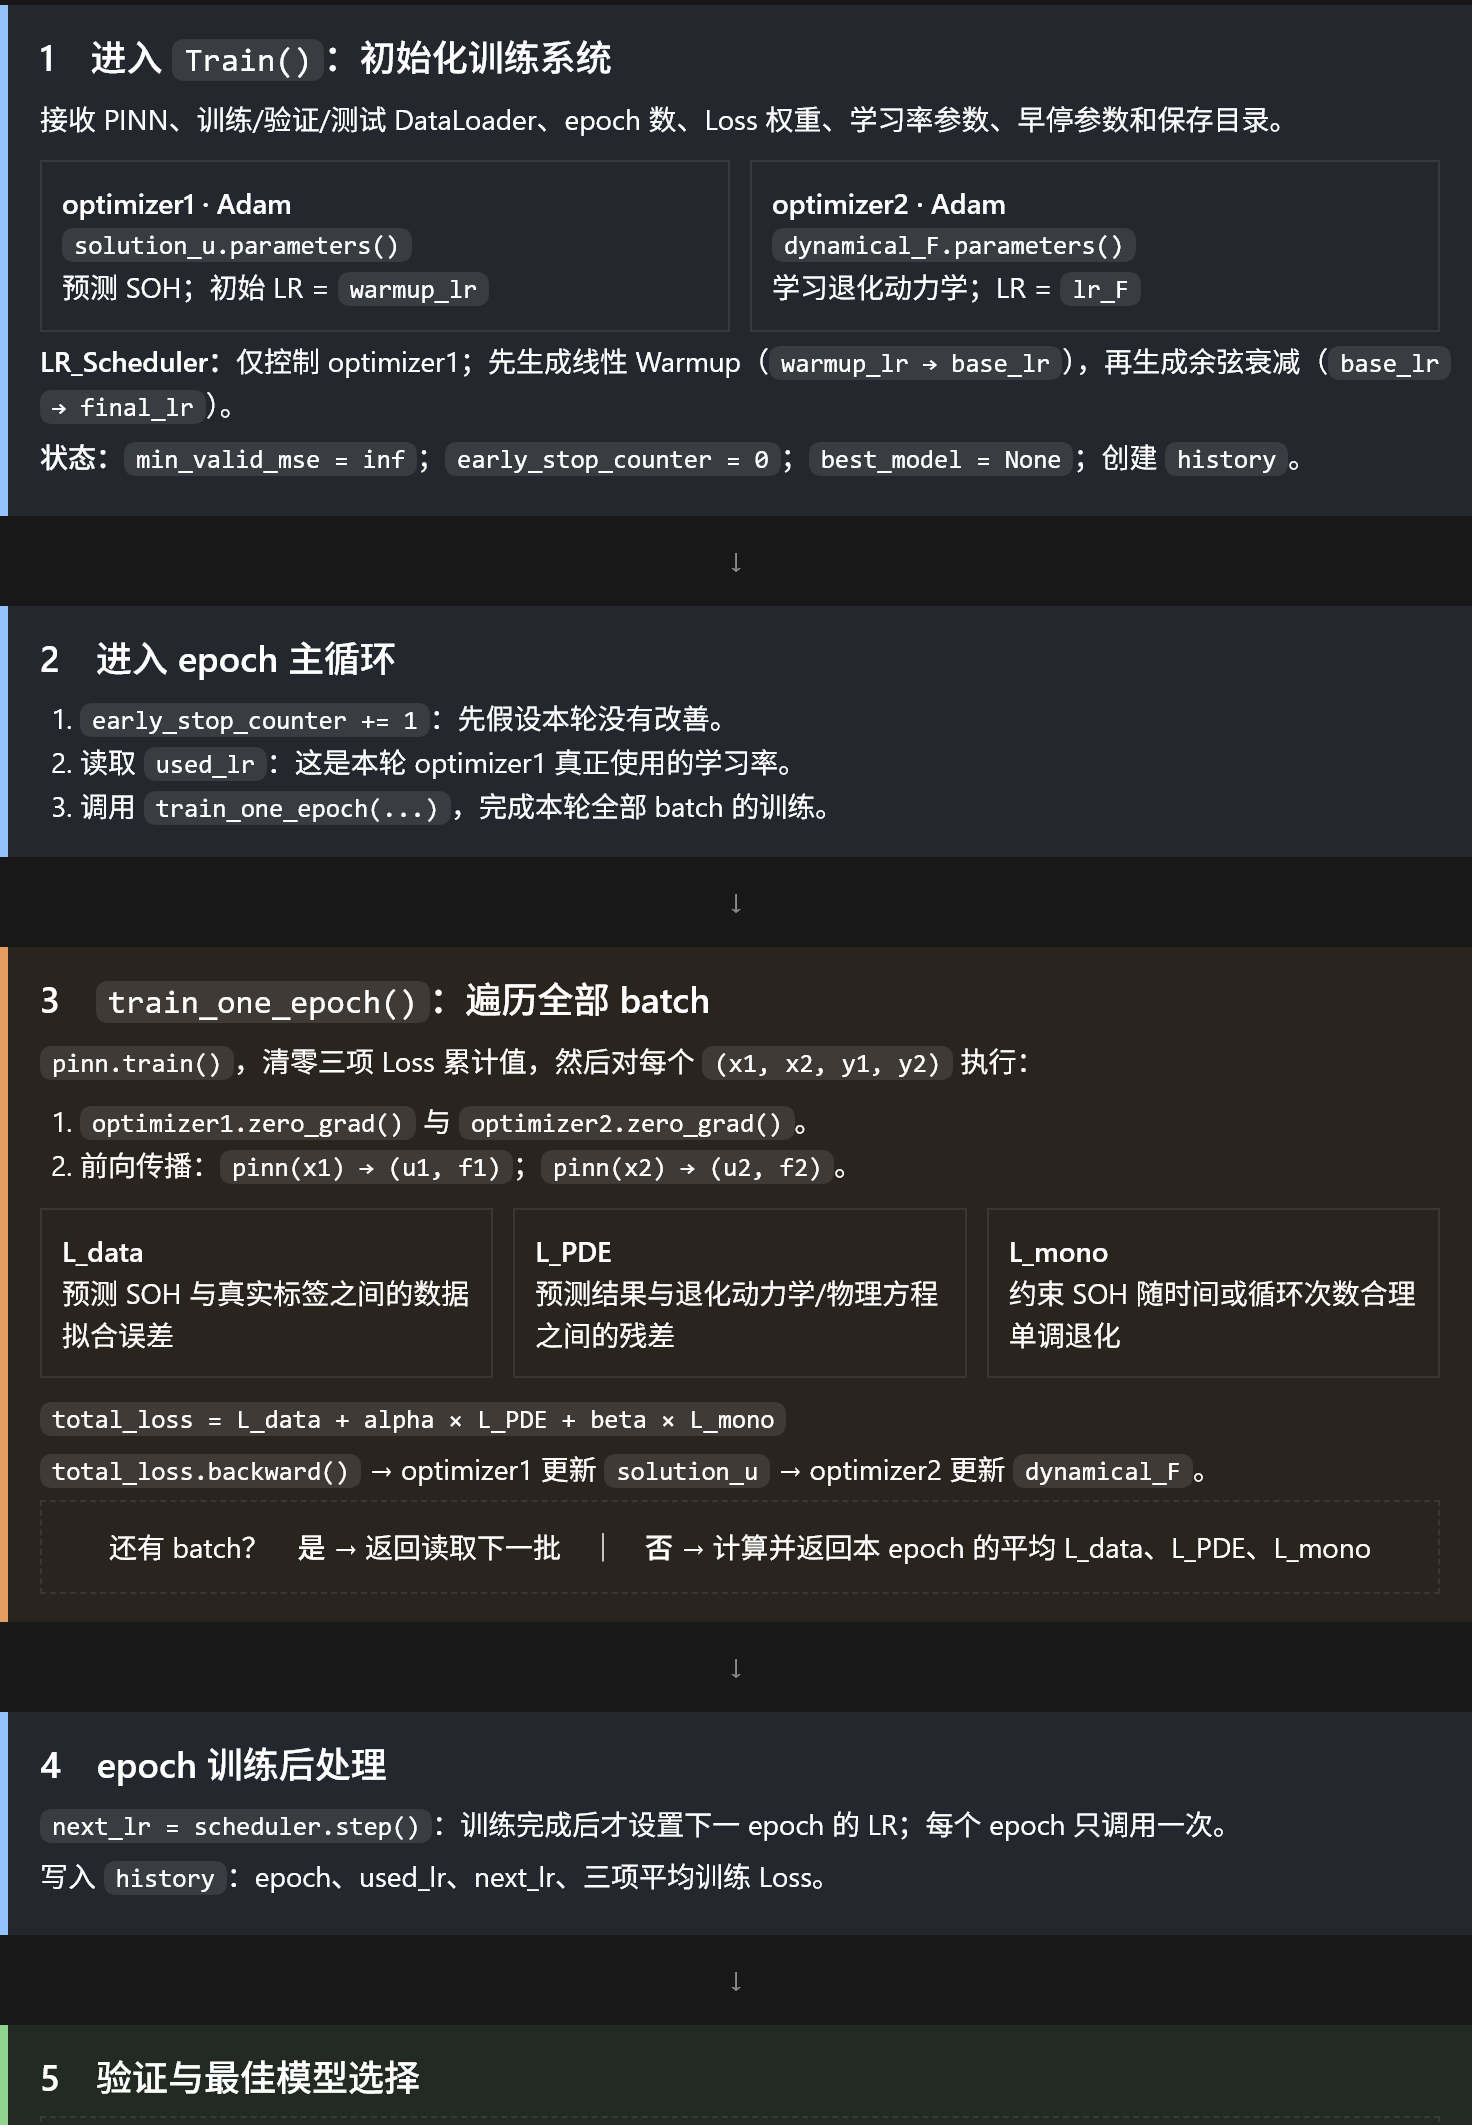

---

### 与原论文的已知差异

| 差异项 | 程度 | 原因 |
|--------|------|------|
| clean_code 中 LR_Scheduler 只有 solution_u 的调度 | 一致 | 原始代码也只对 optimizer1 调度，F 用固定 lr |
| Train() 函数签名独立化 | 重构 | 原始参数在 args 中，拆开使函数更清晰 |
| 日志功能简化 | 功能减少 | 原始代码用 logging 写文件，clean_code 用 print |

---

> **模块 5 总结**：`Train()` 用两个 Adam 优化器分别更新 `solution_u` 与 `dynamical_F`；`optimizer1` 的学习率在每个 epoch 结束后按 warmup+cosine 序列更新，`optimizer2` 保持固定 `lr_F`；验证 MSE 用于选择并恢复最佳模型，早停用于结束长期没有验证改善的训练。